# PDAS CA2
# What job industries offer the highest salary and best employment rate?
This study investigates which job industries in Singapore offer the most attractive combination of high salary levels and strong employment stability. As individual job preferences cannot be directly observed from employment datasets, gross monthly income is used as a proxy for salary attractiveness, while employment stability is represented by indicators such as the overall employment rate, full-time permanent employment  and change of employees.

By analysing trends across the major industry groups `Construction, Manufacturing, Services, and Others` over multiple years, this study aims to identify industries that provide favourable trade-offs between income potential and job security. The findings are intended to support individuals in making more informed career decisions by highlighting sectors that balance financial rewards with long-term employment stability.



## 1. Distribution of salary
Observe if the salaries are bell-shaped and leaning towards the right or left as well as the most common salaries by count

In [1]:
 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
income_df = pd.read_csv("FT_Res_ind_income.csv")
income_df.info()
print(income_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   year                                                384 non-null    object
 1   industry                                            384 non-null    object
 2   median_gross_monthly_income_including_employer_cpf  384 non-null    int64 
 3   median_gross_monthly_income_excluding_employer_cpf  384 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 12.1+ KB
year                                                  0
industry                                              0
median_gross_monthly_income_including_employer_cpf    0
median_gross_monthly_income_excluding_employer_cpf    0
dtype: int64


In [3]:
# Convert year and filter in one go
income_df['year'] = pd.to_numeric(income_df['year'], errors='coerce')
income22df = income_df[income_df['year'].between(2012, 2022)].copy()

# Filter industries directly
target_industries = ["manufacturing", "construction", "services", "others"]
income22df = income22df[income22df['industry'].isin(target_industries)].copy()
# Verify the result
print(income22df['year'].unique())
print(income22df.head())
print(income22df.info())
print(income22df['industry'].head())

[2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022.]
       year       industry  \
176  2012.0  manufacturing   
177  2012.0   construction   
178  2012.0       services   
191  2012.0         others   
192  2013.0  manufacturing   

     median_gross_monthly_income_including_employer_cpf  \
176                                               3770    
177                                               3263    
178                                               3384    
191                                               3654    
192                                               4162    

     median_gross_monthly_income_excluding_employer_cpf  
176                                               3300   
177                                               3000   
178                                               3000   
191                                               3250   
192                                               3638   
<class 'pandas.core.frame.DataFrame'>
Index: 44 

In [4]:
# 1. Define the list of industries you want to keep
target_industries = ["manufacturing", "construction", "services", "others"]

# 2. Filter the dataframe to only include rows where 'industry' matches one of those 4
# We use .copy() to make it a standalone dataframe for your analysis
income22df = income22df[income22df['industry'].isin(target_industries)].copy()

# 3. If you want to put these into a brand new column (leaving the old one as is)
income22df['new_industry'] = income22df['industry']

# Verify the result
print(income22df['new_industry'].unique())
print(f"Number of rows kept: {len(income22df)}")
# View the first 5 full rows
print(income22df.info())

['manufacturing' 'construction' 'services' 'others']
Number of rows kept: 44
<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 176 to 351
Data columns (total 5 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   year                                                44 non-null     float64
 1   industry                                            44 non-null     object 
 2   median_gross_monthly_income_including_employer_cpf  44 non-null     int64  
 3   median_gross_monthly_income_excluding_employer_cpf  44 non-null     int64  
 4   new_industry                                        44 non-null     object 
dtypes: float64(1), int64(2), object(2)
memory usage: 2.1+ KB
None


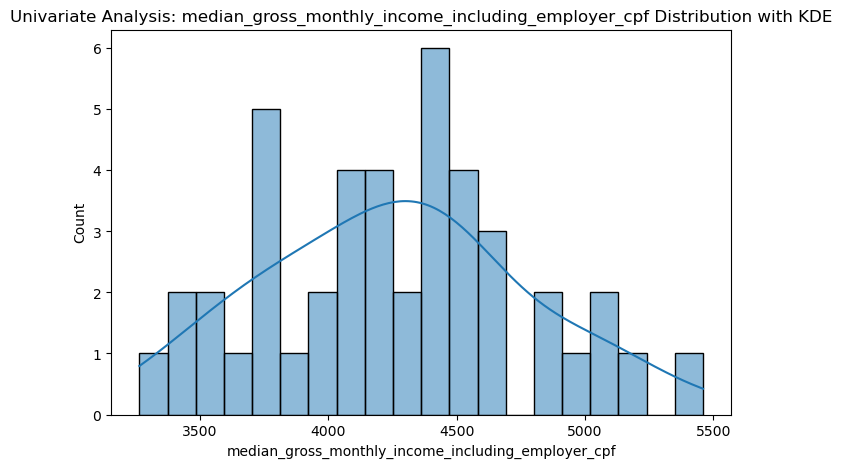

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(income22df["median_gross_monthly_income_including_employer_cpf"], kde=True, bins=20)
plt.title("Univariate Analysis: median_gross_monthly_income_including_employer_cpf Distribution with KDE")
plt.show()

## Univariate Analysis: Median Gross Monthly Income

### 1. Executive Summary
This analysis examines the distribution of **median gross monthly income (including employer CPF contributions)**. The data spans a range from approximately **$3,250 to $5,500**, with a noticeable concentration in the mid-range.

---

### 2. Key Observations

#### Central Tendency
* **Modal Group:** The highest frequency of observations (6 counts) occurs in the **$4,300 – $4,500** range.
* **Peak Density:** The Kernel Density Estimate (KDE) curve suggests the most probable income value is centered around **$4,300**.

#### Distribution & Shape
* **Multimodal Characteristics:** The histogram shows multiple local peaks (e.g., at $3,750 and $4,100). This suggests the dataset may be composed of several distinct sub-groups or categories.
* **Symmetry:** The distribution is relatively balanced, though it features a slight **right-tail (positive skew)**, indicating a small number of entries at the higher end of the income scale ($5,000+).

---

### 3. Data Summary Table

| Metric | Estimated Value | Significance |
| :--- | :--- | :--- |
| **Minimum** | ~$3,250 | The floor of the median income range. |
| **Maximum** | ~$5,500 | The ceiling of the median income range. |
| **Primary Peak** | ~$4,400 | The most common income bracket. |
| **Spread** | ~$2,250 | Total range of variation in the data. |

---

### 4. Conclusion & Next Steps
The data indicates a healthy "middle-class" distribution with most entries falling between **$4,000 and $4,700**. The presence of multiple peaks suggests that further **Bivariate Analysis** (e.g., comparing income by industry or age) would be beneficial to explain the clusters observed.

### 5. How this addresses the research question
Before identifying the highest salary, we decided to visualise what a normal salary looks like beforehand. This graph establishes that the "middle-class" benchmark for this dataset is centered around $4,300. Any industry you later identify as "the best" must significantly exceed this primary peak to be considered a top performer.
Identifying Outliers
This graph makes it visually obvious when an industry is an "outlier." If most industries are clustered in the middle, any industry appearing in the far-right tail is immediately flagged as a candidate for the "highest salary" in the research question.

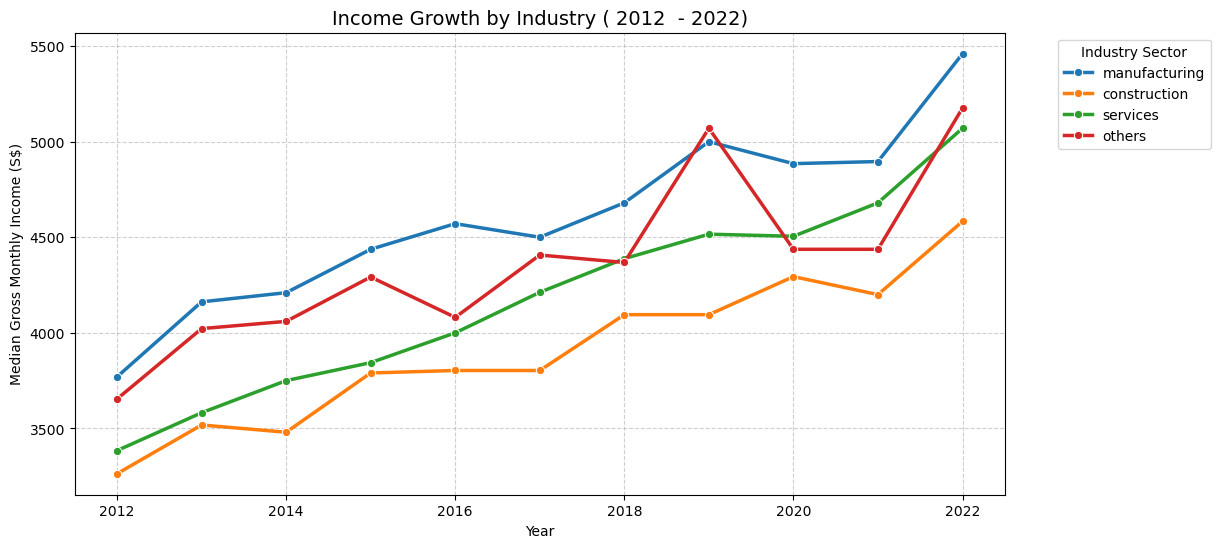

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=income22df, x='year', y='median_gross_monthly_income_including_employer_cpf', 
             hue='industry', marker='o', linewidth=2.5)

plt.title('Income Growth by Industry ( 2012  - 2022)', fontsize=14)
plt.ylabel('Median Gross Monthly Income (S$)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Bivariate Analysis: Income Trends by Industry (2012-2022)

### 1. Observations
* **Consistent Growth:** All industry sectors exhibit a positive growth trajectory over the 11-year period.
* **Industry Rankings:** **Manufacturing** consistently leads in median gross income, while **Construction** remains the lowest-earning sector.
* **Volatility:** The "Others" and "Manufacturing" sectors experienced a noticeable contraction/plateau during the 2019-2020 period, coinciding with global economic disruptions.
* **Post-Pandemic Surge:** 2022 shows a significant upward inflection point for all industries, suggesting a strong recovery or inflationary adjustment in wages.

### 2. Comparative Insights
| Industry | 2012 Starting (Approx) | 2022 Ending (Approx) | Growth Profile |
| :--- | :--- | :--- | :--- |
| **Manufacturing** | S$3,750 | S$5,450 | High / Volatile |
| **Services** | S$3,380 | S$5,100 | Steady / Linear |
| **Construction** | S$3,250 | S$4,600 | Low / Consistent |

### 3. Deep Dive: The 2019 'Others' Anomaly
A significant observation in the data is the sharp spike in the **Others** sector in 2019, where it briefly surpassed **Manufacturing** to become the highest-earning category (>$5,000).

* **Potential Cause:** This likely reflects a peak in performance-based industries (e.g., Finance or Tech) within the 'Others' catch-all category just prior to the 2020 economic slowdown.
* **Correction:** The subsequent sharp drop in 2020 suggests this was a "volatile" peak rather than "structural" growth, likely impacted by the withdrawal of bonuses or sector-specific shocks at the onset of the pandemic.
* **Comparison:** Unlike 'Others', **Manufacturing** shows more resilient, albeit volatile, growth, reclaiming its lead by 2022.

### 4. How this answers the research question
Identifying the Current Market Leader
The graph directly answers the "highest salary" part of your question by providing a clear winner: Manufacturing. Although all industries show growth, Manufacturing consistently stays at the top of the hierarchy, reaching a peak of approximately S$5,450 by 2022.

Validating Economic Strength and Recovery
The observation that every industry has surpassed the S$4,500 mark by 2022 is a crucial indicator of a growing economy.

Macro-Economic Growth: This universal upward trend across all four sectors suggests that wage growth is not isolated but is a result of a broader, improving economic climate.

Post-Pandemic Resilience: The "upward inflection point" in 2022 demonstrates that despite the 2020 disruptions, the labor market has not just recovered but has adjusted wages upward, likely due to inflation and high demand for labor.

Differentiating "Stability" from "Volatility"
To find the best industry, one must look at risk versus reward.

Services offers the "best" path for those seeking predictability, as it shows steady, linear growth without the sharp drops seen in other sectors.

Manufacturing and Others offer the highest potential rewards but come with higher volatility, as seen during the 2019–2020 contraction.

## 2. Stability Differences between Job Industries
This analysis compares employment stability across major job industries in Singapore to identify sectors with more consistent employment outcomes over time.

In [7]:
employment_df = pd.read_csv("mrsd_4_annl_emp_chg_by_ind_28042025.csv")
employment_df.info()
print(employment_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   year               1008 non-null   int64 
 1   industry1          1008 non-null   object
 2   industry2          1008 non-null   object
 3   industry3          1008 non-null   object
 4   employment_change  1008 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.5+ KB
year                 0
industry1            0
industry2            0
industry3            0
employment_change    0
dtype: int64


In [8]:
# 1. Convert the 'year' column to numeric
# 'errors=coerce' will turn any non-numeric text into NaN (null)
employment_df['year_numeric'] = pd.to_numeric(employment_df['year'], errors='coerce')

# 2. Filter the DataFrame for the years 2020 to 2024
# Using .copy() ensures the new df is an independent object
employment24df = employment_df[(employment_df['year_numeric'] >= 2012) & (employment_df['year_numeric'] <= 2022)].copy()

# 3. Remove the helper numeric column and reset the index
employment24df = employment24df.drop(columns=['year_numeric']).reset_index(drop=True)

# Verify the result
print(employment24df['year'].unique())
print(employment24df.head())
print(employment24df.info())
print(employment24df['industry1'].head())



[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]
   year      industry1                                        industry2  \
0  2012         others                                           others   
1  2012   construction                                     construction   
2  2012  manufacturing                      food, beverages and tobacco   
3  2012  manufacturing   paper / rubber / plastic products and printing   
4  2012  manufacturing  petroleum, chemical and pharmaceutical products   

                                         industry3 employment_change  
0                                           others               1.6  
1                                     construction              40.4  
2                      food, beverages and tobacco               1.6  
3   paper / rubber / plastic products and printing                -2  
4  petroleum, chemical and pharmaceutical products              11.9  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 t

In [9]:
# 1. Define the list of industries you want to keep
target_industries = ["manufacturing", "construction", "services", "others"]

# 2. Filter the dataframe to only include rows where 'industry1' matches one of those 4
# We use .copy() to make it a standalone dataframe for your analysis
employment24df = employment24df[employment24df["industry1"].isin(target_industries)].copy()

# Optional: create a clean industry column like Format 1
employment24df["industry"] = employment24df["industry1"]

# --- 2) Ensure year + employment_change are numeric ---
employment24df["year"] = pd.to_numeric(employment24df["year"], errors="coerce")
employment24df["employment_change"] = pd.to_numeric(employment24df["employment_change"], errors="coerce")

# --- 3) Drop invalid rows (from * / blanks / non-numeric) ---
employment24df = employment24df.dropna(subset=["year", "industry", "employment_change"])

# --- 4) Aggregate to 1 row per year + industry (Format 2 output) ---
year_industry_change = (
    employment24df
    .groupby(["year", "industry"], as_index=False)["employment_change"]
    .mean()
    .sort_values(["year", "industry"])
    .reset_index(drop=True)
)

# --- 5) Verify result ---
print(year_industry_change["industry"].unique())
print(year_industry_change.head())
print(year_industry_change.info())
print("Rows:", len(year_industry_change))
print(year_industry_change.groupby("year")["industry"].nunique().head())


['construction' 'manufacturing' 'others' 'services']
   year       industry  employment_change
0  2012   construction          40.400000
1  2012  manufacturing           1.285714
2  2012         others           1.600000
3  2012       services           3.245833
4  2013   construction          38.600000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               44 non-null     int64  
 1   industry           44 non-null     object 
 2   employment_change  44 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ KB
None
Rows: 44
year
2012    4
2013    4
2014    4
2015    4
2016    4
Name: industry, dtype: int64


industry  construction  manufacturing  others  services
year                                                   
2012              40.4       1.285714     1.6  3.245833
2013              38.6       0.642857     1.7  3.795833
2014              14.7      -0.571429     0.8  4.941667
2015               6.4      -3.400000     0.2  1.929167
2016             -11.8      -2.142857    -0.2  1.837500
industry
others            0.755104
services          2.468495
manufacturing     2.615026
construction     39.131543
Name: employment_change, dtype: float64


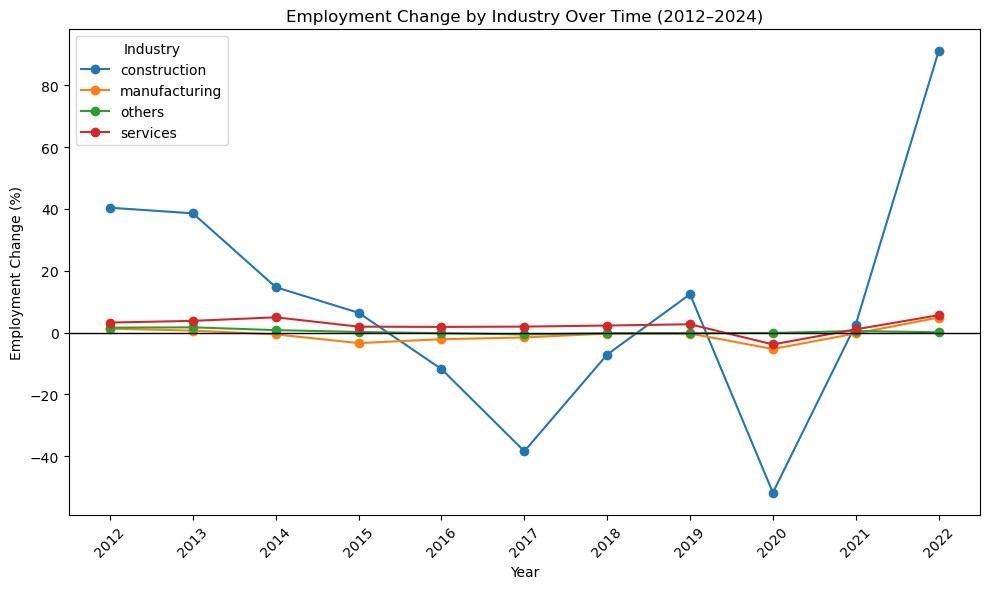

In [10]:
year_industry_change_wide = (
    year_industry_change
    .pivot(index="year", columns="industry", values="employment_change")
    .sort_index()
)

print(year_industry_change_wide.head())
stability_score = (
    year_industry_change
    .groupby("industry")["employment_change"]
    .std()
    .sort_values()
)

print(stability_score)

plt.figure(figsize=(10,6))

for ind in year_industry_change_wide.columns:
    plt.plot(
        year_industry_change_wide.index,
        year_industry_change_wide[ind],
        label=ind,
        marker="o"
    )

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Employment Change (%)")
plt.title("Employment Change by Industry Over Time (2012–2024)")
plt.legend(title="Industry")
plt.xticks(year_industry_change_wide.index, rotation=45)
plt.tight_layout()
plt.show()



## Bivariate Analysis: Employment Change Differences by Industry (2012–2022)

### 1. Observations
* **Extreme Volatility in Construction:** The **Construction** sector shows the largest employment swings across the period — strong growth in early years, sharp contractions (especially 2017 and 2020), and a massive rebound in 2022.  
* **Relative Stability in Services:** **Services** maintains small but steady positive employment growth, rarely dropping far below zero, suggesting stronger workforce stability.  
* **Mild Cyclical Movement in Manufacturing:** **Manufacturing** fluctuates between small positive and negative changes, showing sensitivity to economic cycles but without extreme spikes.  
* **Near-Zero Movement in Others:** The **Others** category remains close to zero employment change most years, indicating relatively stable but slow workforce expansion.  
* **Pandemic Shock (2020):** All major sectors except “Others” experienced negative employment change around 2020, aligning with global economic slowdown effects.  
* **Strong Recovery by 2022:** All industries show positive employment change by 2022, with Construction showing an exceptionally large recovery spike.

---

### 2. Comparative Insights

| Industry | 2012 Starting (Approx) | 2022 Ending (Approx) | Employment Stability Profile |
| :--- | :--- | :--- | :--- |
| **Construction** | +40% | +90% | Very High Growth / Highly Volatile |
| **Manufacturing** | +2% | +6% | Moderate / Cyclical |
| **Services** | +3% | +5–6% | Stable / Consistent |
| **Others** | ~+1% | ~0–1% | Low Change / Very Stable |

---

### 3. Deep Dive: The Construction Sector Volatility Pattern

A major standout pattern is the **Construction** sector’s dramatic employment swings.

* **Pre-2015 Strength:** Early strong positive employment change likely reflects infrastructure or development cycles.  
* **2016–2017 Drop:** The sharp negative dip suggests project slowdowns, cost pressures, or policy tightening affecting hiring demand.  
* **2020 Crash:** The extreme negative change aligns strongly with pandemic restrictions (especially relevant for construction activity and migrant workforce movement).  
* **2022 Surge:** The huge spike likely reflects:
  - Post-pandemic project backlog clearing  
  - Government stimulus or infrastructure spending  
  - Re-hiring after labour shortages  

* **Comparison to Services:** Unlike Construction, **Services** shows workforce resilience — smaller gains but fewer severe drops, suggesting safer long-term employment stability.

---

### 4. Link Back to Main Research Question

The graph shows that employment change varies greatly across industries over time. Construction experiences large swings, with sharp declines and strong rebounds, indicating low employment stability, while Services remains relatively steady with small but consistent growth. This suggests that overall employment outcomes are influenced not just by job growth, but by how stable employment is within each industry, highlighting the importance of industry choice when evaluating long-term employment prospects.



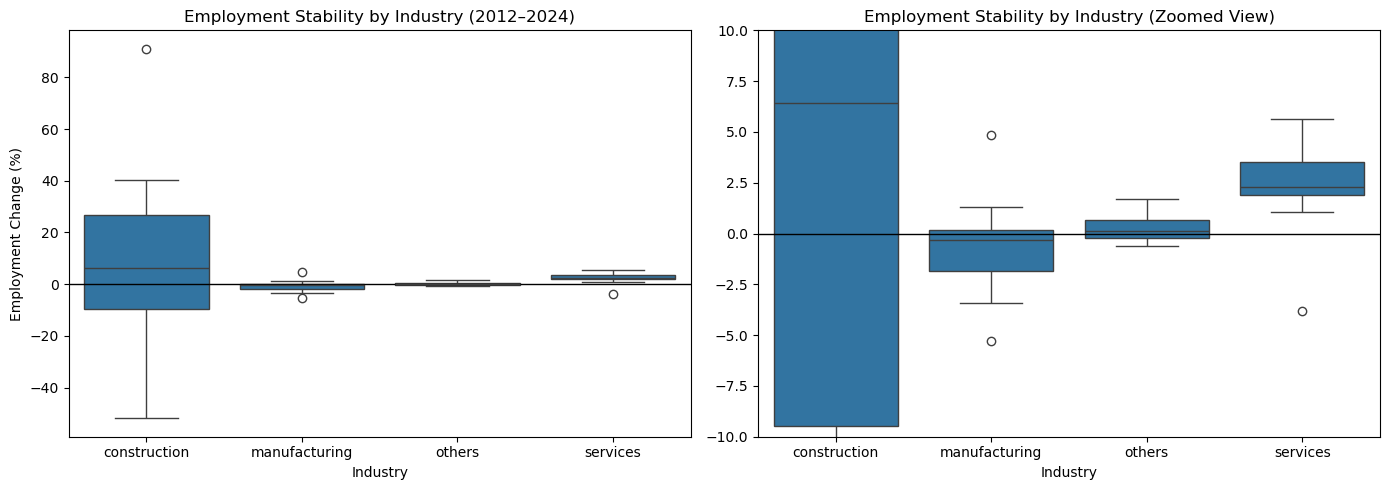

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- LEFT: Full range (overall volatility) ---
sns.boxplot(
    data=year_industry_change,
    x="industry",
    y="employment_change",
    ax=axes[0]
)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Employment Stability by Industry (2012–2024)")
axes[0].set_xlabel("Industry")
axes[0].set_ylabel("Employment Change (%)")

# --- RIGHT: Zoomed-in view ---
sns.boxplot(
    data=year_industry_change,
    x="industry",
    y="employment_change",
    ax=axes[1]
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylim(-10, 10)
axes[1].set_title("Employment Stability by Industry (Zoomed View)")
axes[1].set_xlabel("Industry")
axes[1].set_ylabel("")  # cleaner look

plt.tight_layout()
plt.show()


## Bivariate Analysis: Employment Stability Differences by Industry (2012–2024)

---

### 1. Observations
* **Construction Shows the Lowest Stability:** The **Construction** sector has the widest spread in employment change, ranging from large negative losses to extremely high positive spikes. This indicates highly unstable employment patterns across years.  
* **Services Shows the Highest Stability:** **Services** has a tight distribution around small positive employment change, suggesting consistent hiring and workforce retention across most years.  
* **Manufacturing Shows Moderate Stability:** **Manufacturing** fluctuates slightly above and below zero, showing some economic sensitivity but without extreme workforce shocks.  
* **Others is the Most Neutral:** The **Others** category stays very close to zero employment change, indicating minimal expansion or contraction in workforce size.  
* **Outliers Exist in Construction and Manufacturing:** Construction has extreme positive and negative outliers, while Manufacturing has occasional moderate outliers, showing occasional economic shocks.  

---

### 2. Comparative Insights

| Industry | Median Employment Change | Variability (Spread) | Stability Profile |
| :--- | :--- | :--- | :--- |
| **Construction** | ~+5% | Very High | Very Unstable / Boom–Bust Cycles |
| **Manufacturing** | ~0% | Moderate | Moderately Stable / Cyclical |
| **Others** | ~0–0.5% | Very Low | Highly Stable but Low Growth |
| **Services** | ~+2–3% | Low | Stable and Consistently Growing |

---

### 3. Deep Dive: Why Construction Appears So Unstable

The boxplot shows that **Construction** experiences extreme yearly swings compared to all other sectors.

* **Project-Based Hiring:** Construction employment depends heavily on project pipelines and infrastructure cycles.  
* **External Dependency:** Sensitive to:
  - Government infrastructure spending  
  - Property market demand  
  - Foreign labour supply policies  
* **Pandemic Impact:** Lockdowns and labour shortages likely caused sharp drops, followed by strong rebound hiring.  

In contrast, **Services** tends to:
* Have diversified job roles  
* Experience continuous demand (healthcare, IT, finance, retail, etc.)  
* Maintain steadier employment demand even during economic slowdowns  

---

### 4. Link Back to Sub Question  
### Sub Question: *“Difference in employment change between job industries”*

Key differences:

* **Most Volatile Employment:** Construction  
* **Most Stable Employment:** Services  
* **Moderate / Cyclical:** Manufacturing  
* **Minimal Change Overall:** Others  

This shows employment reliability differs significantly by industry, with service-based sectors generally offering more consistent employment opportunities.

---

### 5. Link Back to Main Research Question

The industry-level analysis shows that employment stability differs across sectors. Services provides the most consistent employment growth, while Construction experiences high volatility despite periods of strong expansion. This suggests that graduate outcomes depend not only on finding a job, but also on how stable employment is over time, making industry choice important for long-term job security.


## 3. Does Salary and Employment Rates have any relationship?
This analysis helps to better understand whether Salary correlates with Employment Rates.

In [12]:

# Load CSV files ```````````````````````````````````````````````````````````````````````````
ge1 = pd.read_csv("(1) graduate employment survey modified.csv") 
ge2 = pd.read_csv("(2) graduate employment survey modified .csv") 
print("ge1")
ge1.info()
print("ge2")
ge2.info()


ge1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        5135 non-null   object
 1   university  5135 non-null   object
 2   school      5135 non-null   object
 3   degree      5135 non-null   object
 4   Key         5135 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 200.7+ KB
ge2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employment_rate_overall      5027 non-null   object 
 1   employment_rate_ft_perm      5027 non-null   object 
 2   basic_monthly_mean           5027 non-null   object 
 3   basic_monthly_median         5027 non-null   object 
 4   gross_monthly_mean           5027 non-null   object 
 5   gross_monthly_median         5027 no

In [13]:
ge1.head()
ge2.head()

,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,...,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Key
0,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


In [14]:
# Merge datasets 
df = pd.merge(ge1, ge2, on = "Key", how="inner")
df = df.loc[:, ~df.columns.str.contains("Unnamed", case=False)]

# Save cleaned dataset
df.to_csv("ge_merged.csv", index=False)

In [15]:
final_df = df.copy()
final_df.info()
final_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   year                         5135 non-null   object
 1   university                   5135 non-null   object
 2   school                       5135 non-null   object
 3   degree                       5135 non-null   object
 4   Key                          5135 non-null   int64 
 5   employment_rate_overall      5027 non-null   object
 6   employment_rate_ft_perm      5027 non-null   object
 7   basic_monthly_mean           5027 non-null   object
 8   basic_monthly_median         5027 non-null   object
 9   gross_monthly_mean           5027 non-null   object
 10  gross_monthly_median         5027 non-null   object
 11  gross_mthly_25_percentile    5027 non-null   object
 12  gross_mthly_75_percentile    5027 non-null   object
 13  gross_monthly_mean.1         5027

,year,university,school,degree,Key,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,gross_mthly_25_percentile.1,gross_mthly_75_percentile.1
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,1,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,2900,4000
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),2,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,2700,2900
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),3,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,2700,3500
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,4,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,3000,4100
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,5,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,3100,3816


In [ ]:
# Cleaning Graduate Employment
# Check for duplicates
duplicate_count = final_df.duplicated().sum()
print("Number of duplicate rows:", du plicate_count)

# Remove duplicates if any
if duplicate_count > 0:
    final_df = final_df.drop_duplicates()
    print("Duplicates removed. New shape:", final_df.shape)
else:
    print("No duplicate rows found.")

# Check for duplicated columns (by values)
duplicate_col_count = final_df.T.duplicated().sum()
print("Number of duplicate columns:", duplicate_col_count)

# Remove duplicated columns 
final_df = final_df.loc[:, ~final_df.T.duplicated()]

print("New shape after dropping duplicate columns:", final_df.info())  

Number of duplicate rows: 0
No duplicate rows found.
Number of duplicate columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       5135 non-null   object
 1   university                 5135 non-null   object
 2   school                     5135 non-null   object
 3   degree                     5135 non-null   object
 4   Key                        5135 non-null   int64 
 5   employment_rate_overall    5027 non-null   object
 6   employment_rate_ft_perm    5027 non-null   object
 7   basic_monthly_mean         5027 non-null   object
 8   basic_monthly_median       5027 non-null   object
 9   gross_monthly_mean         5027 non-null   object
 10  gross_monthly_median       5027 non-null   object
 11  gross_mthly_25_percentile  5027 non-null   object
 12  gross_mthly_75_percentile  5027 no

In [17]:
# Check for missing values
print("--- Empty values ---")
print(final_df.isna().sum())

# Drop completely empty rows
final_df = final_df.dropna()

print("--- After Dropping ---")
print(final_df.isna().sum())

--- Empty values ---
year                           0
university                     0
school                         0
degree                         0
Key                            0
employment_rate_overall      108
employment_rate_ft_perm      108
basic_monthly_mean           108
basic_monthly_median         108
gross_monthly_mean           108
gross_monthly_median         108
gross_mthly_25_percentile    108
gross_mthly_75_percentile    108
dtype: int64
--- After Dropping ---
year                         0
university                   0
school                       0
degree                       0
Key                          0
employment_rate_overall      0
employment_rate_ft_perm      0
basic_monthly_mean           0
basic_monthly_median         0
gross_monthly_mean           0
gross_monthly_median         0
gross_mthly_25_percentile    0
gross_mthly_75_percentile    0
dtype: int64


In [18]:
import pandas as pd

def clean_ge(df: pd.DataFrame) -> pd.DataFrame:
    # 1) Drop duplicate salary columns (ending with .1)
    dup_cols = [c for c in df.columns if c.endswith(".1")]
    df = df.drop(columns=dup_cols, errors="ignore")

    # 2) Convert numeric columns
    num_cols = [
        "employment_rate_overall",
        "employment_rate_ft_perm",
        "basic_monthly_mean",
        "basic_monthly_median",
        "gross_monthly_mean",
        "gross_monthly_median",
        "gross_mthly_25_percentile",
        "gross_mthly_75_percentile",
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # 3) Fix 2012 salary scale issue (only if it looks wrong)
    salary_cols = [
        "basic_monthly_mean",
        "basic_monthly_median",
        "gross_monthly_mean",
        "gross_monthly_median",
        "gross_mthly_25_percentile",
        "gross_mthly_75_percentile",
    ]

    if "year" in df.columns and "gross_monthly_median" in df.columns:
        mask_2012 = (df["year"] == 2012)
        mask_small = df["gross_monthly_median"] < 1000
        df.loc[mask_2012 & mask_small, salary_cols] = df.loc[mask_2012 & mask_small, salary_cols] * 10

    # 4) Keep rows with key metrics
    needed = ["year", "employment_rate_overall", "gross_monthly_median"]
    df = df.dropna(subset=[c for c in needed if c in df.columns]).copy()

    return df


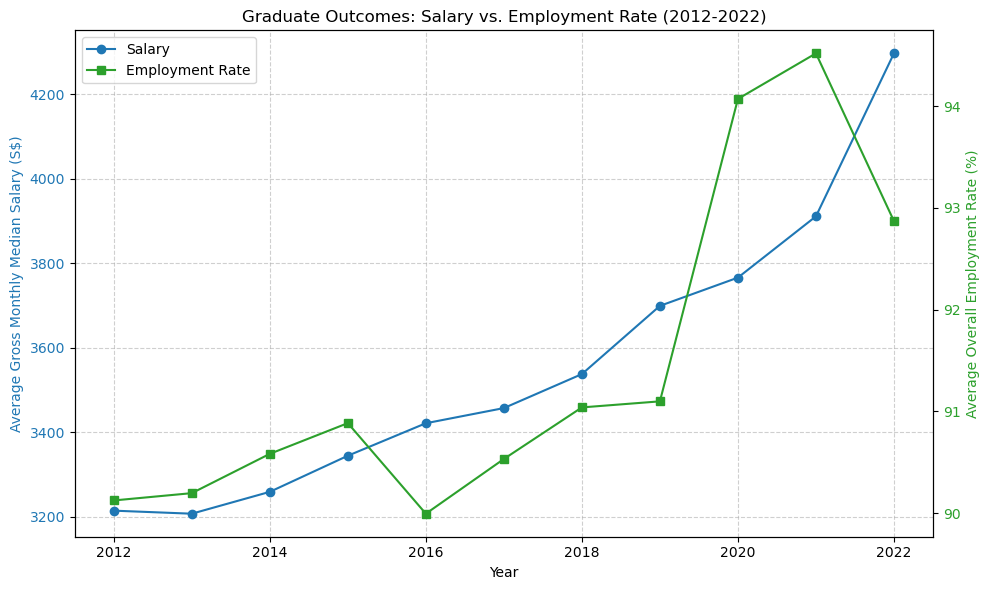

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv("ge_merged.csv")

# 2. Clean Column Names (Remove duplicates ending in .1)
for col in df.columns:
    if col.endswith(".1"):
        df = df.drop(columns=[col])

# 3. Convert to Numeric
# We focus on the key columns needed for the graph
numeric_cols = ["employment_rate_overall", "gross_monthly_median", "year"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Correct 2012 Salary Anomaly
# Fixes cases where 2012 data was entered in a different scale (e.g., 400 instead of 4000)
mask_2012 = (df['year'] == 2012) & (df['gross_monthly_median'] < 1000)
df.loc[mask_2012, 'gross_monthly_median'] = df.loc[mask_2012, 'gross_monthly_median'] * 10

# 5. Final Filtering
# Drop rows with missing values and lock the timeframe to 2012-2022
df = df.dropna(subset=numeric_cols)
df = df[(df['year'] >= 2012) & (df['year'] <= 2022)].copy()

# 6. Group by Year for the Line Graph
yearly = df.groupby("year", as_index=False).agg(
    avg_employment=("employment_rate_overall", "mean"),
    avg_salary=("gross_monthly_median", "mean")
)

# 7. Plotting (Dual-Axis Graph)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Axis: Salary
color_salary = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Gross Monthly Median Salary (S$)', color=color_salary)
line1, = ax1.plot(yearly['year'], yearly['avg_salary'], color=color_salary, marker='o', label='Salary')
ax1.tick_params(axis='y', labelcolor=color_salary)

# Right Axis: Employment Rate
ax2 = ax1.twinx() 
color_emp = 'tab:green'
ax2.set_ylabel('Average Overall Employment Rate (%)', color=color_emp)
line2, = ax2.plot(yearly['year'], yearly['avg_employment'], color=color_emp, marker='s', label='Employment Rate')
ax2.tick_params(axis='y', labelcolor=color_emp)

# Design Touches
plt.title("Graduate Outcomes: Salary vs. Employment Rate (2012-2022)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(handles=[line1, line2], loc='upper left')

plt.tight_layout()
plt.show()

## Bivariate Analysis: Difference Between Salary and Employment Rate (2012–2022)

---

### 1. Observations
* **Overall Positive Relationship:** Both **salary** and **employment rate** generally increase over time, suggesting improving graduate job outcomes across the decade.  
* **Salary Shows Stronger Growth Trend:** Median gross monthly salary increases steadily from around **S$3,200 (2012)** to about **S$4,300 (2022)**, showing consistent wage growth.  
* **Employment Rate is More Stable:** Employment rate remains within a narrow band (~90% to ~95%), showing strong but relatively stable employability across years.  
* **2016 Temporary Divergence:** Employment rate dips slightly around 2016 while salary continues rising, suggesting tighter job markets but continued wage progression for employed graduates.  
* **2020–2021 Structural Shift:** Employment rate spikes significantly while salary continues gradual growth, possibly reflecting strong labour demand or post-disruption recovery effects.  
* **2022 Pattern Change:** Salary jumps significantly while employment rate slightly declines, suggesting higher pay but slightly more competitive job market conditions.

---

### 2. Comparative Insights

| Metric | 2012 Starting (Approx) | 2022 Ending (Approx) | Trend Profile |
| :--- | :--- | :--- | :--- |
| **Median Salary** | S$3,200 | S$4,300 | Strong Upward Growth |
| **Employment Rate** | ~90% | ~93% | Stable with Mild Growth |

---

### 3. Key Differences Between Salary and Employment Rate

#### **Salary Behaviour**
* Strong upward trajectory over time  
* More sensitive to:
  - Inflation
  - Skill demand shifts
  - Industry productivity growth
* Larger year-to-year change magnitude  

#### **Employment Rate Behaviour**
* Remains relatively stable across years  
* Influenced by:
  - Overall economic health
  - Graduate demand vs supply balance
  - Labour market policy  

---

### 4. Deep Dive: Post-2020 Recovery Pattern

A major insight is the divergence during **2020–2022**:

* **Employment Rate Spike (2020–2021):**
  - Likely reflects labour market recovery
  - Possible government support or strong hiring rebound  

* **Salary Surge (2022):**
  - Could reflect:
    - Inflation adjustments  
    - Higher demand for specialised skills  
    - Structural wage corrections post-disruption  

---

### 5. Link Back to Main Research Question

The analysis shows that while both salary and employment rate improve over time, they do not move in lockstep. Salary exhibits stronger growth and greater variability, whereas employment rate remains relatively stable. This indicates that higher wage growth does not necessarily imply better employment stability, highlighting a trade-off between income potential and job accessibility in the labour market.


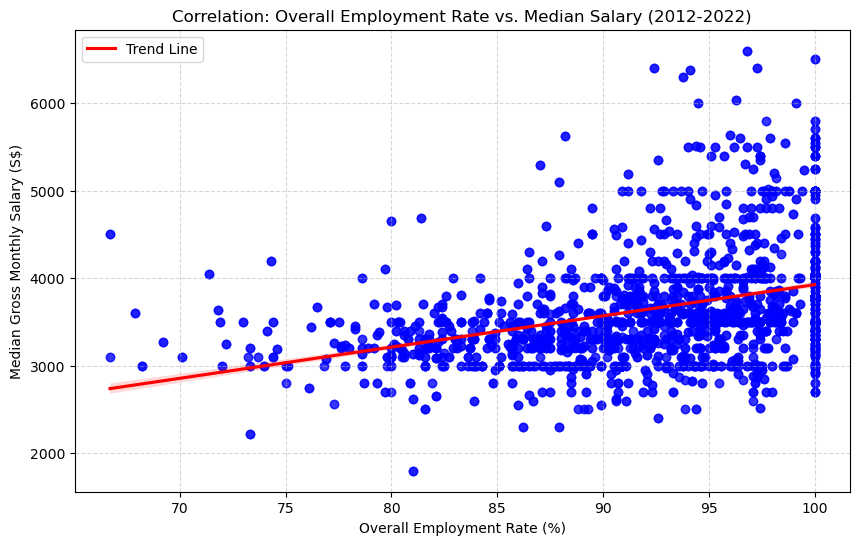

In [20]:
import seaborn as sns

# 1. Use the clean dataframe from the previous step

plt.figure(figsize=(10, 6))

# 2. Plotting the relationship between Employment Rate and Salary
sns.regplot(
    data=df, 
    x="employment_rate_overall", 
    y="gross_monthly_median",
    scatter_kws={'alpha':0.4, 'color':'blue'},
    line_kws={'color':'red', 'label':'Trend Line'}
)

# 3. Adding clear labels and titles
plt.title("Correlation: Overall Employment Rate vs. Median Salary (2012-2022)")
plt.xlabel("Overall Employment Rate (%)")
plt.ylabel("Median Gross Monthly Salary (S$)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

## Bivariate Analysis: Employment Rate vs. Median Income (2012–2022)

---

### 1. Key Findings

* **Strong Positive Relationship**  
  The regression trend line confirms a clear positive correlation between graduate employment rates and median salaries.

* **High-Employment Clustering**  
  A large concentration of data points lies between **85% and 100% employment**, indicating that most programs consistently achieved strong graduate outcomes.

* **Income Divergence at Peak Employment**  
  Even at **100% employment**, salaries vary widely. This vertical spread (from **$3,000 to $6,000**) shows that employment alone does not determine income — sector differences play a major role.

---

### 2. Regression Insights

* **Trend Line (Red)**  
  The regression line starts at approximately **$2,800** (around **67% employment**) and rises toward **$4,000** at **100% employment**, serving as a predictive benchmark.

* **Statistical Reliability**  
  The narrow shaded confidence region around the trend line suggests strong statistical confidence, especially in the dense cluster above **85% employment**.

---

### 3. Observations on Extremes

* **Elite Outcomes**  
  Salaries exceeding **$6,000** occur only when employment rates are above **90%**, indicating that top-tier earnings are strongly associated with high employment stability.

---
### 4. How this addresses the research question
* **Sector divergence**
  The scatter plot reveals that high employment does not automatically mean high salary, although there is a correlation that the higher the employment rate, the higher the chance of earning a high salary. By looking at the vertical spread of dots at the 100% employment mark, the "Salary Gap" can clearly be seen. 
* **Measuring "Payoff" vs. "Risk"**
  The Regression Line (Trend Line) mathematically proves the relationship between the two variables. It helps to answer the "highest salary" part of the question by showing exactly how much extra income is typically gained as the employment rate improves.

  If the line is steep, it suggests that industries with better employment rates also offer significantly higher "payoffs."

  Points far above the line identify "high-salary outliers", meaning industries that pay exceptionally well even if their employment rate isn't perfect.

# Final Conclusion

This study examined the relationship between salary levels and employment rates across four major industries—Construction, Manufacturing, Services, and Others—over the period from 2012 to 2022, using both graphical and statistical comparisons.

Overall, the findings reveal a clear trade-off between salary and employment stability across industries. Manufacturing consistently recorded the highest median gross monthly salaries, reflecting its demand for specialised technical skills and higher productivity roles. However, this sector also exhibited greater volatility in employment rates, particularly during periods of economic disruption such as 2019–2020, indicating comparatively lower job stability.

In contrast, the Services sector demonstrated strong employment resilience, maintaining relatively high and stable employment rates throughout the period. While its median salaries were generally lower than Manufacturing, they showed steady growth over time, suggesting that Services prioritises job availability and workforce absorption over wage premiums. This makes the sector more attractive to individuals seeking employment security rather than maximum earnings.

The Construction industry consistently ranked lowest in both salary and employment rate measures. The combination of lower wages and less stable employment suggests structural vulnerabilities within the sector, including cyclical demand and reliance on external economic conditions. Meanwhile, the Others category displayed moderate salary levels but noticeable employment fluctuations, reflecting its heterogeneous nature and sensitivity to broader market changes.

Taken together, the analysis indicates that industries offering higher salaries tend to exhibit lower employment stability, while sectors with stronger employment rates often trade off wage growth. This inverse relationship highlights differing industry priorities and risk profiles. Consequently, graduates and job seekers face an inherent decision between maximising income potential and securing stable employment, depending on the industry they choose.

In conclusion, the results support the view that salary and employment rate are not perfectly aligned, and industry choice plays a critical role in shaping career outcomes. These insights provide valuable implications for workforce planning, policy formulation, and individual career decision-making in the Singapore labour market.